In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cns.data_utils import load_data, out_path, data_path

# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
data = load_data()

In [3]:
def clip_data(data, threshold):
    clipped = np.clip(data, 0, threshold)
    rest = data[data > threshold]
    return clipped, rest

In [4]:
def plot_data(data, dataset, thrs):
    cns = data[dataset].cns
    # create three subplots
    fig, axs = plt.subplots(2, 2, figsize=(18, 10))
    plt.subplots_adjust(hspace=0.25)

    types = ["major_cn", "minor_cn"]
    for cn_type in types:
        cn_data, rest = clip_data(cns[cn_type], thrs)
        values = cn_data.to_numpy().flatten().astype(int)
        cn_range, counts = np.unique(values, return_counts=True)
        occurences = counts / counts.sum() * 100
        ax = axs[0][types.index(cn_type)]
        ax.bar(cn_range, occurences);
        ax.set_ylabel("Occurence (%)")
        ax.set_xticks(cn_range)
        ax.set_title(f"{cn_type} clipped to {thrs}")
        for i, v in enumerate(occurences):
            ax.text(cn_range[i], v + 0.5, f"{v:.2f}%", ha='center', fontsize=8)
        ax = axs[1][types.index(cn_type)]
        ax.hist(rest, bins=50);    
        ax.set_title(f"Clipped {cn_type}: {len(rest) / cn_data.size:.2%} - ({len(rest)} / {cn_data.size})")
        ax.set_xlabel("Copy number")
        ax.set_ylabel("Occurence")
    plt.suptitle(f"Clipped copy number distribution for {dataset}")

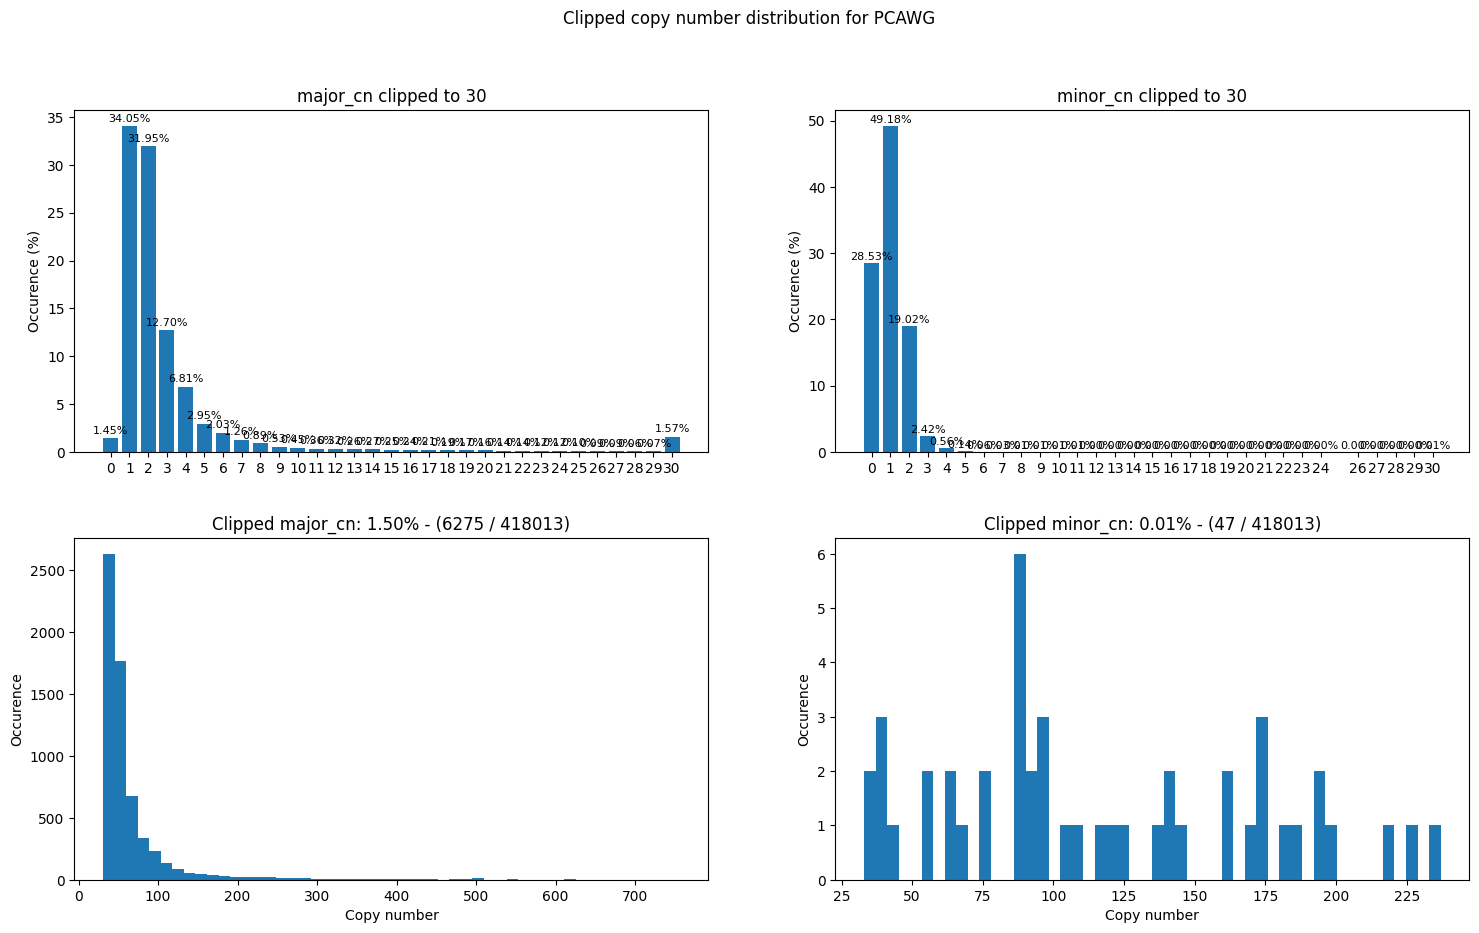

In [5]:
plot_data(data, "PCAWG", 30)

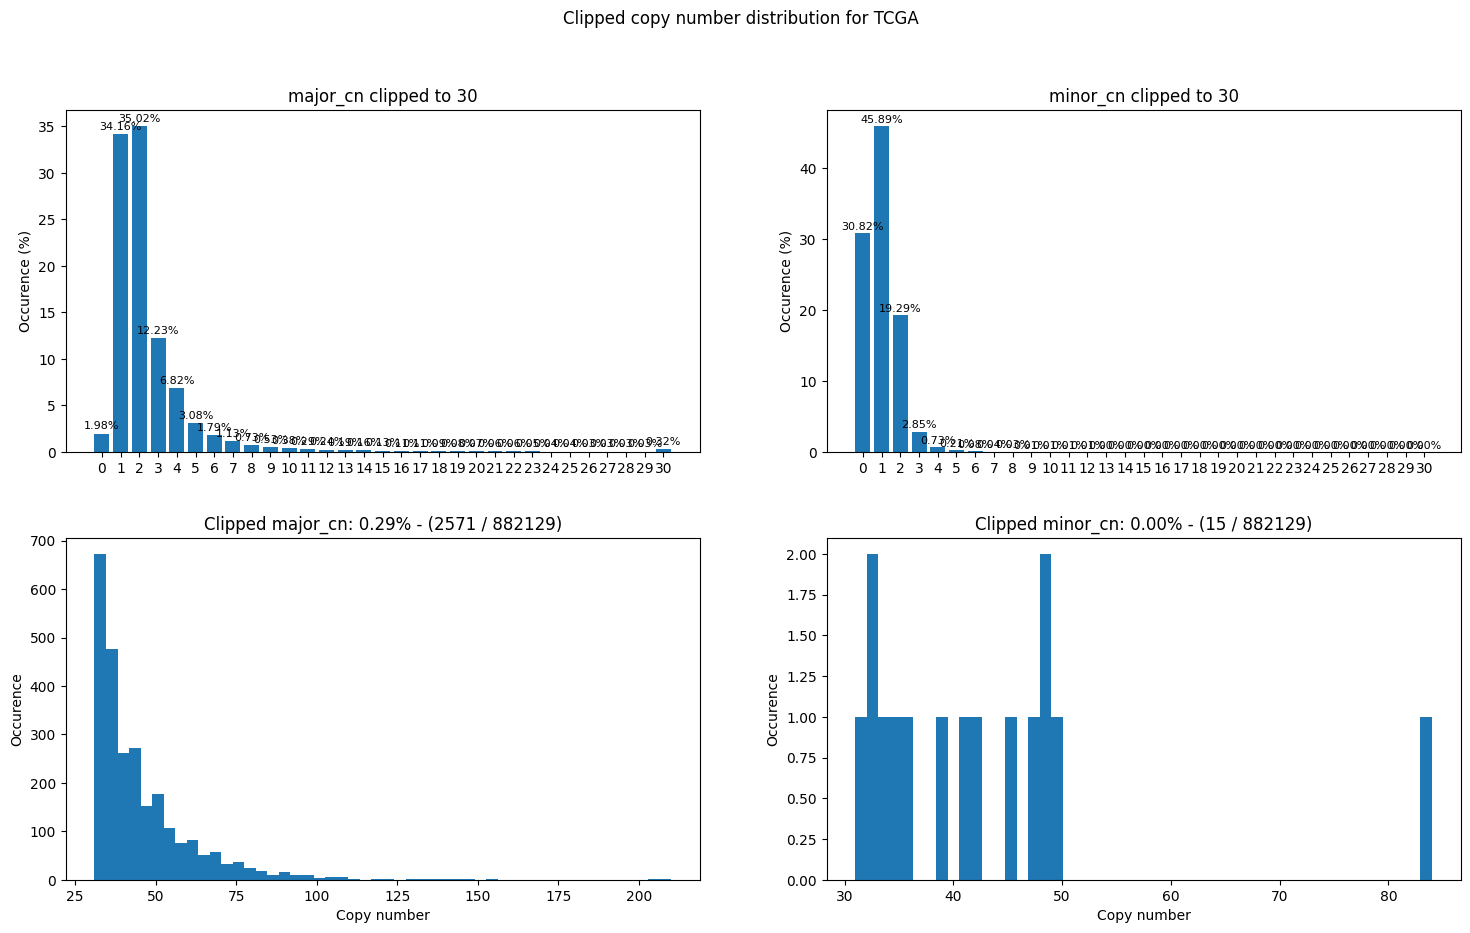

In [6]:
plot_data(data, "TCGA", 30)

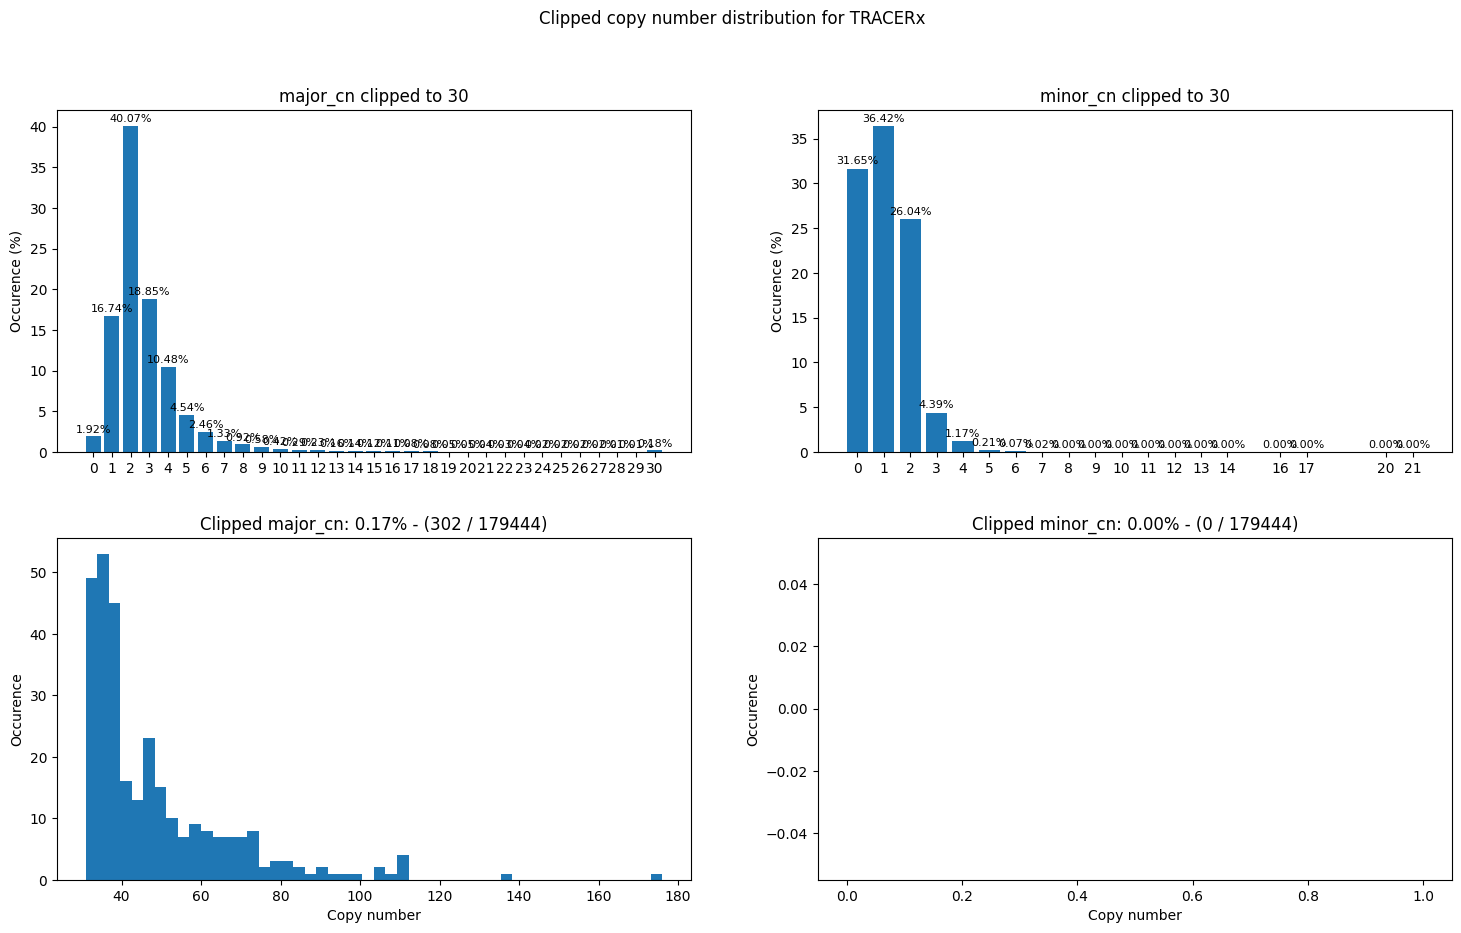

In [7]:
plot_data(data, "TRACERx", 30)

In [8]:
def plot_over_dist(data, dataset, thrs):	
    fig, axs = plt.subplots(1, 2,  figsize=(10, 4))


    # Plot for major_cn
    cns = data[dataset].cns
    above = cns.query(f"major_cn > {thrs}").copy().reset_index(drop=True)
    above["len"] = above["end"] - above["start"]
    above["mid"] = above["start"] + above["len"] / 2
    axs[0].hist(above["mid"], bins=300, weights=above["len"])
    axs[0].set_title('major_cn')
    axs[0].set_ylabel('Length of region')
    axs[0].set_xlabel('Genomic position')

    # Plot for minor_cn
    below = cns.query(f"minor_cn > {thrs}").copy().reset_index(drop=True)
    below["len"] = below["end"] - below["start"]
    below["mid"] = below["start"] + below["len"] / 2
    axs[1].hist(below["mid"], bins=300, weights=below["len"])
    axs[1].set_title('minor_cn')
    axs[1].set_xlabel('Genomic position')

    plt.suptitle(f"Copy number distribution over genome for {dataset} clipped to {thrs}")

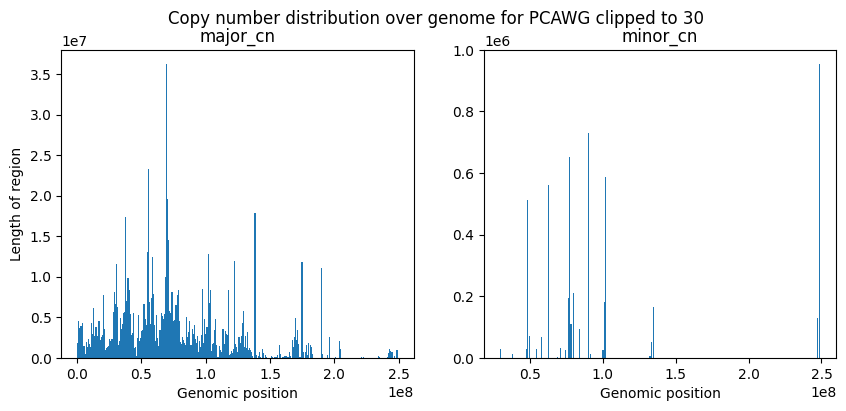

In [9]:
plot_over_dist(data, "PCAWG", 30)

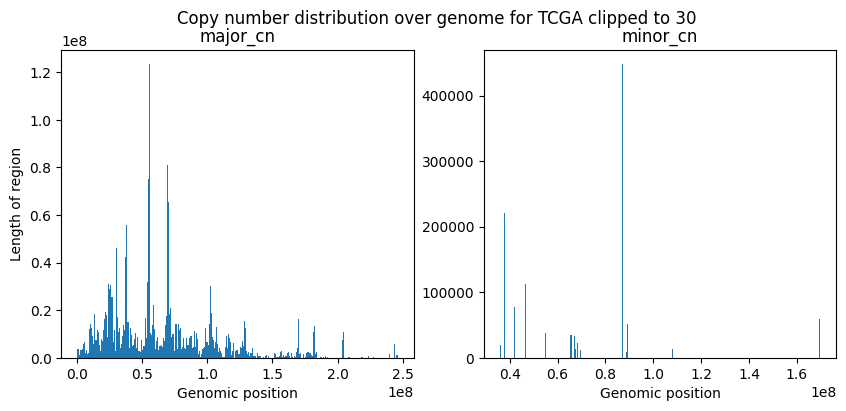

In [10]:
plot_over_dist(data, "TCGA", 30)

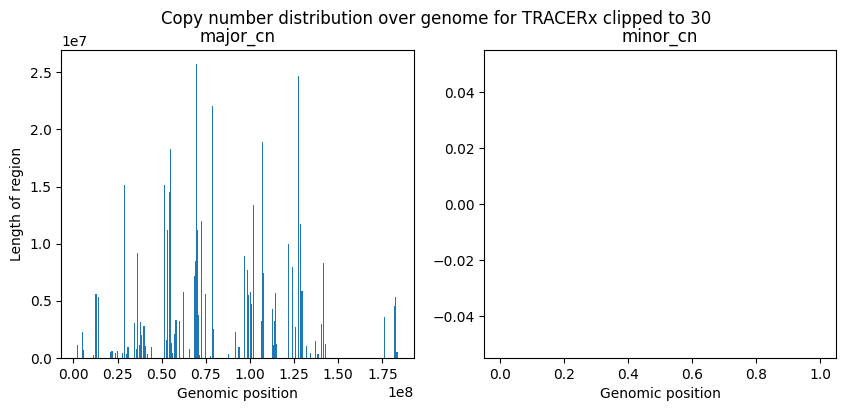

In [11]:
plot_over_dist(data, "TRACERx", 30)